In [1]:
%load_ext autoreload
%autoreload 2

from pklib.indicators import *
from pklib.utilities import *
from pklib.pkindicators import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
# import pkindicators  # Assuming your C module is compiled and installed as pkindicators

# Generate sample data (you should replace this with real OHLCV data)
# dates = pd.date_range('2022-01-01', periods=1000, freq='D')
# prices = np.random.randn(1000).cumsum() + 100  # Simulated price data
# data = pd.DataFrame(prices, columns=['close'], index=dates)

import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

In [2]:

import sysconfig
cmodule = 'pkindicators'
f'clear & rm {cmodule}.so & gcc -shared -o {cmodule}.so -fPIC {cmodule}.c -I{sysconfig.get_path("include")} -I{np.get_include()}'

'clear & rm pkindicators.so & gcc -shared -o pkindicators.so -fPIC pkindicators.c -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include'

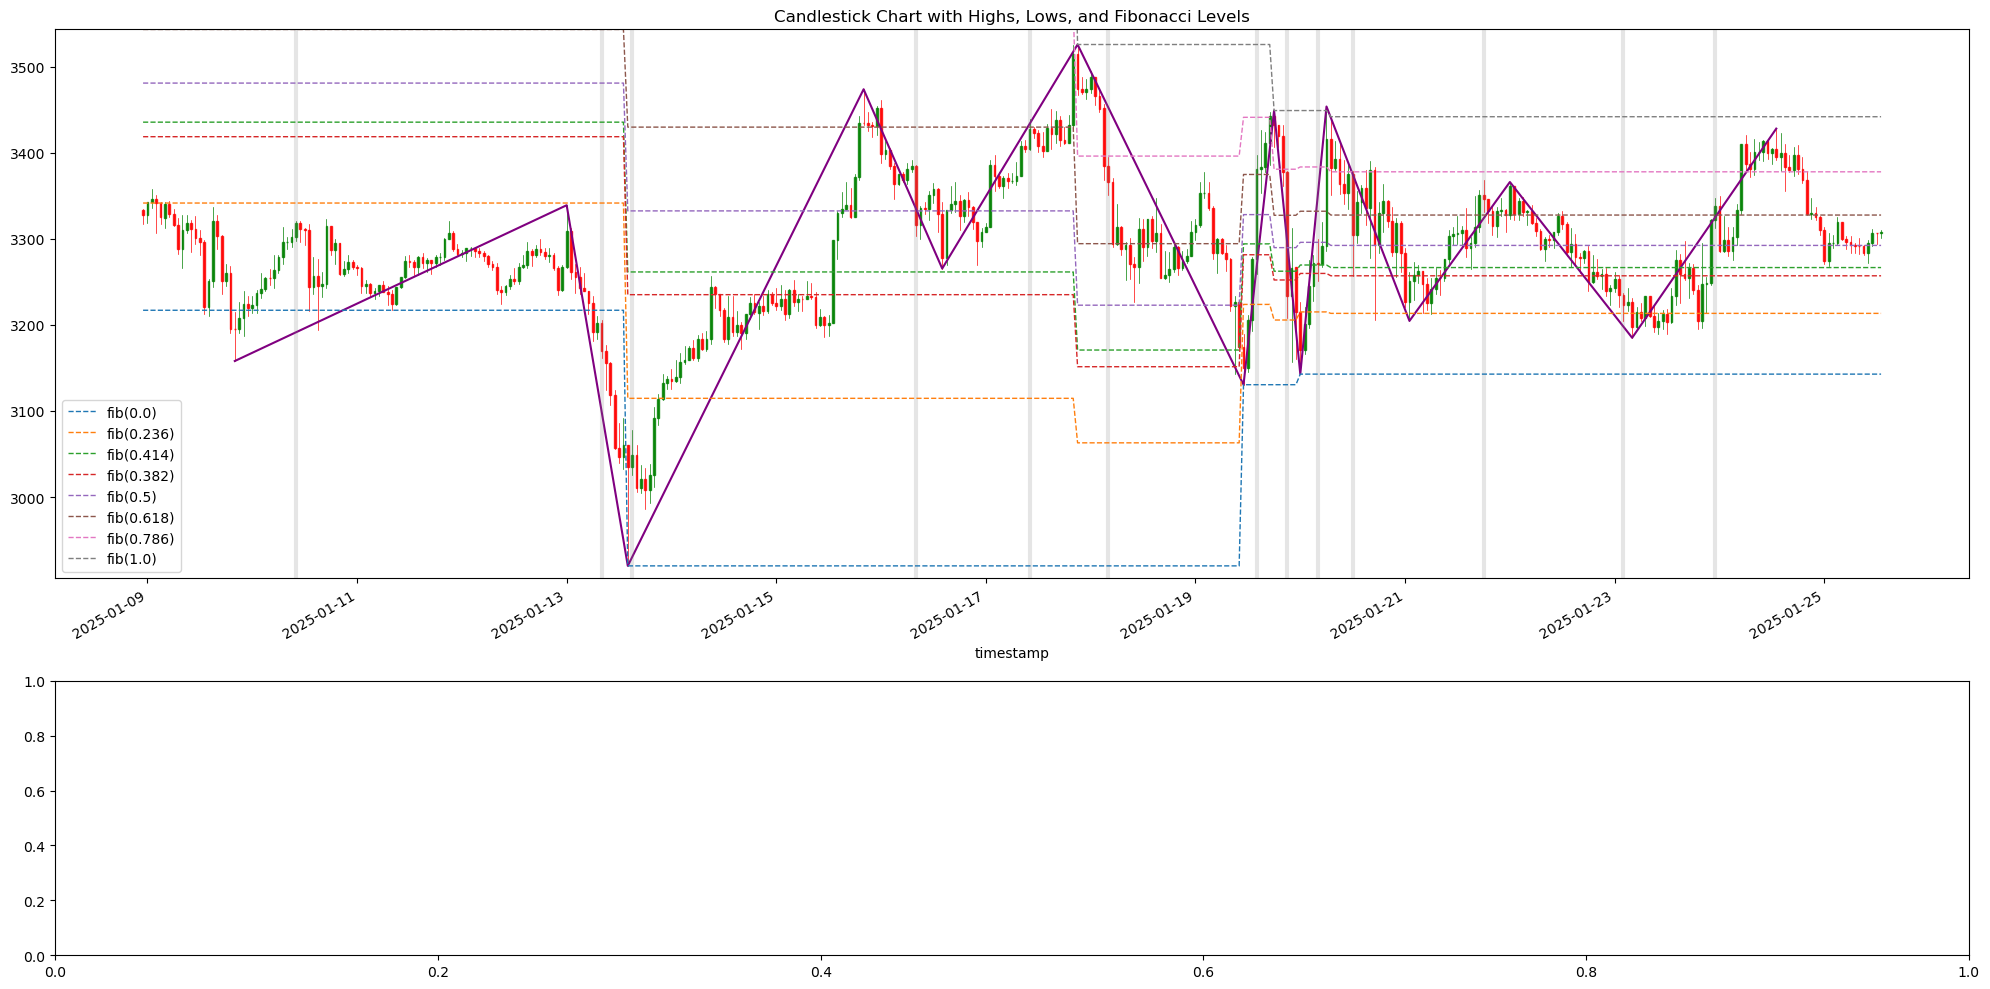

In [ ]:
# fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.414, -0.382, -0.236, 0.0, 0.236, 0.382, 0.414, 0.5, 0.618, 0.786, 1.0, 1.236, 1.5, 1.618, 1.786, 2.0, 2.236, 2.382, 2.5, 2.628, 2.786, 3, 3.382, 3.618, 4, 5])
# fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.414, -0.382, -0.236, 0.0, 0.236, 0.382, 0.414, 0.5, 0.618, 0.786, 1.0, 1.236, 1.414, 1.5, 1.618, 1.786, 2.0])
fib_levels = np.array([0.0, 0.236, 0.414, 0.382, 0.5, 0.618, 0.786, 1.0])

fib_columns = [f'fib({fib})' for fib in fib_levels]

exchange,base,quote,timeframe = 'binance','ETH', 'USDT', '1h'
data = load_candles(exchange,base,quote,timeframe)#.apply(np.log)
epsilon = 0.05
highs = data['high'].values
lows = data['low'].values
# highs = lows = data.close.values
# Call the calculate_zigzag function from the C module
high_low_markers, turning_markers = calculate_zigzag(highs, lows, epsilon=epsilon)

extreme_points_ix = np.where(high_low_markers != 0)[0]
extreme_points = high_low_markers[extreme_points_ix]
extreme_prices = np.where(extreme_points == 1, highs[extreme_points_ix], lows[extreme_points_ix])

turning_points_ix = np.where(turning_markers !=0)[0]


# running_highs_idx = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * np.arange(len(data)), index=data.index).ffill().values
# running_lows_idx = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * np.arange(len(data)), index=data.index).ffill().values

##############################################

fhigh_low_markers, fturning_markers = calculate_zigzag(highs, lows, epsilon=epsilon * 1)

running_highs = pd.Series(np.where(fhigh_low_markers == 1, 1, np.nan) * highs).ffill().values
running_lows = pd.Series(np.where(fhigh_low_markers == -1, 1, np.nan) * lows).ffill().values

diff = running_highs - running_lows
fib_matrix = np.outer(diff, fib_levels)
fib_levels_array = running_lows[:, np.newaxis] + fib_matrix
df_fibs = pd.DataFrame(fib_levels_array, columns=fib_columns, index=data.index)

##############################################
##############################################
ws, ww = len(data)-1000, 400
wdata = data.iloc[ws:ws+ww-1].copy()

whighs = wdata.high
wlows = wdata.low

candlestick_ohlc_args={'width': .1 / np.log(len(wdata))}

##############################################
# Create the figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), height_ratios=[2, 1])

wdata['date_num'] = mdates.date2num(wdata.index)
# Prepare the OHLC data in the format: (date, open, high, low, close)
ohlc = wdata[['date_num', 'open', 'high', 'low', 'close']].values
# Plot the candlesticks
candlestick_ohlc(ax1, ohlc, colorup='green', colordown='red', alpha=0.8, **candlestick_ohlc_args)
# Set y-axis limits based on the close price
ax1.set_ylim(wlows.min()*0.995, whighs.max()*1.005)

# Format the x-axis to show dates
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.set_title('Candlestick Chart with Highs, Lows, and Fibonacci Levels')
# ax1.legend()
wturning_points_ix = turning_points_ix[(turning_points_ix >= ws) & (turning_points_ix <= ws + ww - 1)]
wextreme_points_ix = extreme_points_ix[(extreme_points_ix >= ws) & (extreme_points_ix <= ws + ww - 1)]
wextreme_points = high_low_markers[wextreme_points_ix]
wextreme_prices = np.where(wextreme_points == 1, highs[wextreme_points_ix], lows[wextreme_points_ix])

# turning_dates = mdates.date2num(wdata.loc[turning_points_idx].index)
ax1.plot(data.index[wextreme_points_ix], wextreme_prices, color='purple', label='ZigZag Line', lw=1.5)
for ix in wturning_points_ix:
    ax1.axvline(data.index.values[ix], color='gray', linestyle='-', alpha=0.2, lw=3)

df_fibs.loc[wdata.index].plot(ax=ax1, linestyle='--', lw=1)

plt.tight_layout()
plt.show()

In [ ]:
running_lows.shape, fib_matrix.shape

In [ ]:
lclose = data.close.apply(np.log)
turning_closes = lclose.iloc[turning_points_ix]
(turning_closes - turning_closes.shift()).cumsum().plot()